# Project 4: Deep Learning Systems
## Image Classification on CIFAR-10 with a Convolutional Neural Network

**Name:** Timothy

**Dataset:** [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) (Krizhevsky, 2009), obtained via `torchvision.datasets.CIFAR10` (auto-downloads the official archive from https://www.cs.toronto.edu/~kriz/cifar.html on first run and caches it in `./data`).

**Task type:** Image-based task using a **Convolutional Neural Network (CNN)**, implemented in PyTorch. This is a **supervised, multi-class image classification** problem: given a 32x32 color photograph, predict which of 10 object categories it belongs to.

**Why this dataset:** CIFAR-10 contains 60,000 real, hand-labeled photographs (50,000 train / 10,000 test) split evenly across 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck) -- enough samples to meaningfully train and evaluate a CNN. It is a standard, publicly available academic benchmark (not synthetic or AI-generated), and it is unrelated to the datasets used in Projects 1-3 (Iris flowers, UCI Adult/Census Income, and Breast Cancer Wisconsin Diagnostic).

**Dataset access:** The dataset is not stored as static files in this submission. Instead, `torchvision.datasets.CIFAR10(root="./data", download=True)` downloads and caches it automatically the first time the notebook is run; `./data` is excluded from version control via `.gitignore` since the raw archive is about 170 MB.

**Project description:** This notebook loads and inspects CIFAR-10, trains a baseline CNN, trains a second CNN that differs from the baseline by one deliberate change (added dropout regularization), evaluates and compares both models, and interprets the results.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Data Ingestion and Inspection

In [2]:
# Normalize using CIFAR-10's known per-channel mean/std
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

# Hold out part of the training set for validation during training
val_size = 5000
train_size = len(train_full) - val_size
train_set, val_set = random_split(
    train_full, [train_size, val_size], generator=torch.Generator().manual_seed(RANDOM_STATE)
)

classes = train_full.classes
print(f"Classes ({len(classes)}): {classes}")
print(f"Training samples: {len(train_set)}, Validation samples: {len(val_set)}, Test samples: {len(test_set)}")

image, label = train_full[0]
print(f"Image tensor shape: {tuple(image.shape)}, dtype: {image.dtype}")
print(f"Label example: {label} ({classes[label]})")

Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Training samples: 45000, Validation samples: 5000, Test samples: 10000
Image tensor shape: (3, 32, 32), dtype: torch.float32
Label example: 6 (frog)


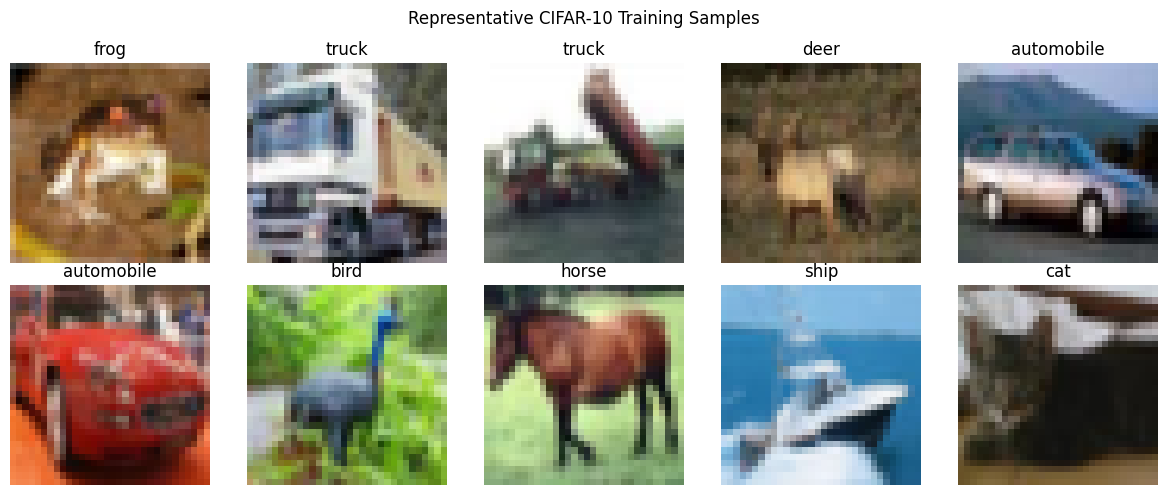

In [3]:
# Display representative samples
def unnormalize(img_tensor):
    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_full[i]
    ax.imshow(unnormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(classes[label])
    ax.axis("off")
plt.suptitle("Representative CIFAR-10 Training Samples")
plt.tight_layout()
plt.show()

In [4]:
# Check class balance in the training set
train_labels = [train_full.targets[i] for i in range(len(train_full))]
counts = np.bincount(train_labels)
for cls, count in zip(classes, counts):
    print(f"{cls:>12}: {count}")

    airplane: 5000
  automobile: 5000
        bird: 5000
         cat: 5000
        deer: 5000
         dog: 5000
        frog: 5000
       horse: 5000
        ship: 5000
       truck: 5000


**Data quality and preprocessing notes:** Each image is a 32x32 RGB photograph, loaded as a `(3, 32, 32)` float tensor with pixel values normalized to roughly zero mean and unit variance per channel using CIFAR-10's published per-channel statistics; normalization like this helps gradient-based optimization converge more reliably than raw 0-255 pixel values would. The training set is perfectly balanced at 5,000 images per class, so no class-imbalance handling is needed. There are no missing values in the sense a tabular dataset would have (every image is a complete, fixed-size array), but 5,000 of the 50,000 training images were held out as a validation set (not used for weight updates) so training progress could be monitored on unseen data without touching the official test set.

## Baseline Model: CNN Architecture

**Design choices:** The baseline is a small convolutional neural network with two convolution-ReLU-pooling blocks followed by two fully connected layers:
- **Block 1:** `Conv2d(3, 32, kernel_size=3, padding=1)` -> `ReLU` -> `MaxPool2d(2)`. The 3x3 kernel with padding=1 preserves spatial size before pooling, and 32 filters give the network enough capacity to learn basic edge/color/texture detectors. Max pooling halves the spatial resolution (32x32 -> 16x16) and adds translation tolerance.
- **Block 2:** `Conv2d(32, 64, kernel_size=3, padding=1)` -> `ReLU` -> `MaxPool2d(2)`. Doubling the channel count to 64 while halving spatial size again (16x16 -> 8x8) is a standard CNN pattern: as spatial detail is discarded, channel capacity is increased so the network can represent more complex, combined features.
- **Fully connected head:** the resulting `64 x 8 x 8` feature map is flattened and passed through `Linear(64*8*8, 128)` -> `ReLU` -> `Linear(128, 10)`, producing 10 raw class scores (logits), one per CIFAR-10 category.

ReLU activations are used throughout the hidden layers because they are computationally cheap and avoid the vanishing-gradient problems associated with sigmoid/tanh activations in deeper networks (LeCun, Bengio, & Hinton, 2015). No activation is applied to the final output layer because the loss function used for training (`CrossEntropyLoss`) expects raw logits and applies the softmax internally.

In [5]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16 -> 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


baseline_model = BaselineCNN().to(device)
n_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(baseline_model)
print(f"\nTrainable parameters: {n_params:,}")

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

Trainable parameters: 545,098


## Baseline Model: Training

**Loss and optimizer:** `CrossEntropyLoss` is the standard choice for multi-class classification with integer labels, since it combines a log-softmax with negative log-likelihood in a single numerically stable operation. `Adam` was chosen as the optimizer because it adapts the learning rate per parameter and typically converges faster than plain SGD on small-to-medium CNNs without extensive learning-rate tuning (Kingma & Ba, 2015). The model is trained for a fixed number of epochs, and both training and validation loss/accuracy are recorded after every epoch so training progress can be inspected directly rather than only looking at a final number.

In [6]:
BATCH_SIZE = 128
NUM_EPOCHS = 8
LEARNING_RATE = 1e-3

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)


def run_epoch(model, loader, criterion, optimizer=None):
    """Run one pass over `loader`. If `optimizer` is given, trains (updates weights);
    otherwise evaluates in inference mode. Returns (average_loss, accuracy)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total


def train_model(model, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    """Train `model` for `num_epochs`, returning a history dict of per-epoch
    train/validation loss and accuracy."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    return history

In [7]:
print("Training baseline model...\n")
baseline_history = train_model(baseline_model)

Training baseline model...



Epoch 1/8 | train_loss=1.3999 train_acc=0.5013 | val_loss=1.1283 val_acc=0.6020


Epoch 2/8 | train_loss=1.0244 train_acc=0.6407 | val_loss=0.9619 val_acc=0.6654


Epoch 3/8 | train_loss=0.8674 train_acc=0.6983 | val_loss=0.8985 val_acc=0.6838


Epoch 4/8 | train_loss=0.7540 train_acc=0.7377 | val_loss=0.8485 val_acc=0.7016


Epoch 5/8 | train_loss=0.6608 train_acc=0.7688 | val_loss=0.8235 val_acc=0.7172


Epoch 6/8 | train_loss=0.5773 train_acc=0.7985 | val_loss=0.8216 val_acc=0.7178


Epoch 7/8 | train_loss=0.4981 train_acc=0.8277 | val_loss=0.8723 val_acc=0.7164


Epoch 8/8 | train_loss=0.4217 train_acc=0.8546 | val_loss=0.9112 val_acc=0.7128


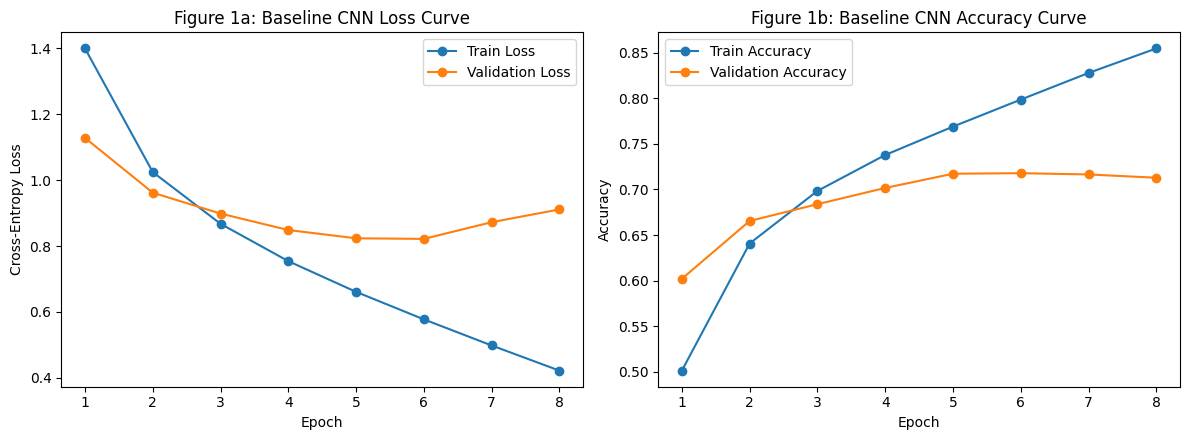

In [8]:
# Figure 1: Baseline training/validation loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, baseline_history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_range, baseline_history["val_loss"], marker="o", label="Validation Loss")
axes[0].set_title("Figure 1a: Baseline CNN Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()

axes[1].plot(epochs_range, baseline_history["train_acc"], marker="o", label="Train Accuracy")
axes[1].plot(epochs_range, baseline_history["val_acc"], marker="o", label="Validation Accuracy")
axes[1].set_title("Figure 1b: Baseline CNN Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Experimental Comparison: Adding Dropout Regularization

**What was changed:** The experimental model has the exact same convolutional and fully connected layer sizes as the baseline, with one addition: a `Dropout(p=0.5)` layer inserted between the two fully connected layers in the classifier head. Everything else -- number of layers, number of filters/units, activation functions, loss function, optimizer, learning rate, batch size, and number of epochs -- is held identical to the baseline.

**Why this change was selected:** This isolates a **regularization strategy** change (one of the three allowed change categories) rather than mixing it with an architecture or hyperparameter change, so any performance difference can be attributed specifically to dropout. Dropout randomly zeroes a fraction of activations during training, which prevents units from co-adapting too closely to specific training examples and is a well-established technique for reducing overfitting in neural networks (Srivastava, Hinton, Krizhevsky, Sutskever, & Salakhutdinov, 2014).

**How the setup differs from the baseline:** The only code difference is the added `nn.Dropout(0.5)` layer in the classifier (active only during training; PyTorch automatically disables it during `model.eval()`). The same train/validation/test split, preprocessing, loss function, optimizer, learning rate, batch size, and number of epochs are reused so the comparison isolates this one change.

In [9]:
class DropoutCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(dropout_p),  # <-- the one deliberate change vs. BaselineCNN
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


dropout_model = DropoutCNN().to(device)
n_params_dropout = sum(p.numel() for p in dropout_model.parameters() if p.requires_grad)
print(f"Trainable parameters (dropout model): {n_params_dropout:,} "
      f"(same as baseline: {n_params_dropout == n_params})")

print("\nTraining experimental (dropout) model...\n")
dropout_history = train_model(dropout_model)

Trainable parameters (dropout model): 545,098 (same as baseline: True)

Training experimental (dropout) model...



Epoch 1/8 | train_loss=1.5723 train_acc=0.4300 | val_loss=1.2281 val_acc=0.5706


Epoch 2/8 | train_loss=1.2202 train_acc=0.5646 | val_loss=1.0382 val_acc=0.6318


Epoch 3/8 | train_loss=1.0773 train_acc=0.6190 | val_loss=0.9538 val_acc=0.6696


Epoch 4/8 | train_loss=0.9895 train_acc=0.6533 | val_loss=0.9006 val_acc=0.6880


Epoch 5/8 | train_loss=0.9134 train_acc=0.6781 | val_loss=0.8690 val_acc=0.6944


Epoch 6/8 | train_loss=0.8560 train_acc=0.6965 | val_loss=0.8326 val_acc=0.7144


Epoch 7/8 | train_loss=0.8106 train_acc=0.7122 | val_loss=0.8413 val_acc=0.7050


Epoch 8/8 | train_loss=0.7647 train_acc=0.7300 | val_loss=0.7982 val_acc=0.7210


## Evaluation and Comparison

In [10]:
def evaluate_on_test(model, loader):
    """Run `model` over the test loader and return (y_true, y_pred) as numpy arrays."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


def summarize_performance(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro")
    rec = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")
    print(f"{name}: accuracy={acc:.4f}  macro-precision={prec:.4f}  "
          f"macro-recall={rec:.4f}  macro-F1={f1:.4f}")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


y_true_base, y_pred_base = evaluate_on_test(baseline_model, test_loader)
y_true_drop, y_pred_drop = evaluate_on_test(dropout_model, test_loader)

baseline_metrics = summarize_performance("Baseline CNN  ", y_true_base, y_pred_base)
dropout_metrics = summarize_performance("Dropout CNN   ", y_true_drop, y_pred_drop)

Baseline CNN  : accuracy=0.7071  macro-precision=0.7126  macro-recall=0.7071  macro-F1=0.7042
Dropout CNN   : accuracy=0.7187  macro-precision=0.7197  macro-recall=0.7187  macro-F1=0.7181


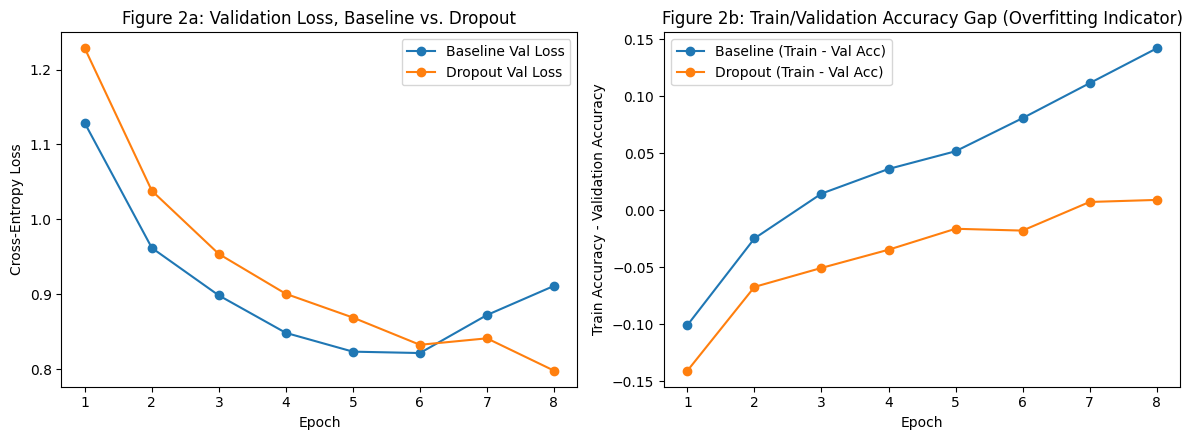

In [11]:
# Figure 2: Baseline vs. Dropout -- validation loss and train/validation accuracy gap
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, baseline_history["val_loss"], marker="o", label="Baseline Val Loss")
axes[0].plot(epochs_range, dropout_history["val_loss"], marker="o", label="Dropout Val Loss")
axes[0].set_title("Figure 2a: Validation Loss, Baseline vs. Dropout")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()

baseline_gap = np.array(baseline_history["train_acc"]) - np.array(baseline_history["val_acc"])
dropout_gap = np.array(dropout_history["train_acc"]) - np.array(dropout_history["val_acc"])
axes[1].plot(epochs_range, baseline_gap, marker="o", label="Baseline (Train - Val Acc)")
axes[1].plot(epochs_range, dropout_gap, marker="o", label="Dropout (Train - Val Acc)")
axes[1].set_title("Figure 2b: Train/Validation Accuracy Gap (Overfitting Indicator)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Train Accuracy - Validation Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

comparison = pd.DataFrame(
    {
        "Baseline": {
            "Final train accuracy": baseline_history["train_acc"][-1],
            "Final val accuracy": baseline_history["val_acc"][-1],
            "Train-Val gap (final epoch)": baseline_gap[-1],
            "Test accuracy": baseline_metrics["accuracy"],
            "Test macro-F1": baseline_metrics["f1"],
        },
        "Dropout": {
            "Final train accuracy": dropout_history["train_acc"][-1],
            "Final val accuracy": dropout_history["val_acc"][-1],
            "Train-Val gap (final epoch)": dropout_gap[-1],
            "Test accuracy": dropout_metrics["accuracy"],
            "Test macro-F1": dropout_metrics["f1"],
        },
    }
).round(4)
comparison

,Baseline,Dropout
Final train accuracy,0.8546,0.7300
Final val accuracy,0.7128,0.7210
Train-Val gap (final epoch),0.1418,0.0090
Test accuracy,0.7071,0.7187
Test macro-F1,0.7042,0.7181


**Comparison and trade-offs:** By the final epoch, the baseline model reached 85.5% training accuracy but only 71.3% validation accuracy (a 14.2-point gap), and its validation loss (Figure 1a) actually started increasing after epoch 6 while training loss kept falling -- a clear sign of overfitting. The dropout model reached only 73.0% training accuracy but 72.1% validation accuracy (a 0.9-point gap), and its validation loss decreased smoothly through all 8 epochs (Figure 2a) with no sign of turning back up. On the held-out test set, this translated into the dropout model slightly **outperforming** the baseline (71.9% vs. 70.7% accuracy; macro-F1 0.718 vs. 0.704) despite having *lower* training accuracy -- exactly the trade-off dropout is designed to produce: it sacrifices some ability to fit the training data in exchange for a model that generalizes better to unseen data. The cost of this change was training convergence: the dropout model's training accuracy climbed more slowly, so it may need more epochs to reach its own performance ceiling.

## Summary

This notebook trained a convolutional neural network in PyTorch to classify CIFAR-10 images into 10 object categories, comparing a baseline CNN (two conv-ReLU-pool blocks plus two fully connected layers) against an identical model with one change: a dropout layer added before the final classification layer. The baseline reached 70.7% test accuracy but showed clear overfitting, with a 14.2-point gap between training and validation accuracy and a validation loss that started rising after epoch 6. Adding dropout closed that gap to under 1 point and, despite converging more slowly on the training data, slightly improved test accuracy to 71.9%, demonstrating that regularization can improve real generalization even at the cost of training-set performance. The most unexpected outcome was that the dropout model did not just reduce overfitting but actually beat the baseline on held-out data, which is not guaranteed by dropout in general and depended on this specific architecture and epoch budget. A challenge was keeping the comparison fair: both models used the same data split, preprocessing, loss function, optimizer, learning rate, batch size, and number of epochs, so the only plausible explanation for the difference in results is the one architectural change that was made.